# 07｜完整 Forensics Adapter 訓練與 FF++ 測試

使用官方 Forensics Adapter 專案的完整模型，取代 05 的特徵層 Adapter。

架構組成：

- 凍結的 CLIP ViT-L/14 主幹。
- 平行的 TinyViT 前八層作為 Adapter。
- CLIP 第 1、8、15 層的淺層特徵注入 Adapter。
- Adapter 產生的 attention bias 回饋至 CLIP。
- Blending-boundary（x-ray）監督。
- Adapter 與 CLIP 的 patch-wise contrastive loss。
- CLIP sample-wise contrastive loss。
- Real／Fake 分類 loss。

總參數 435,163,337，可訓練 7,546,823（1.7%），CLIP 主幹可訓練參數為 0。

**比較上的限制**：資料沿用相同的 FF++ 切分、YOLO 裁臉與每部影片 16 幀，但既有基準（03）使用 ViT-B/16，本方法使用 ViT-L/14。因此此處的增益混合了「更大的主幹」與「Adapter 結構」兩個因素，無法完全歸因於後者。若要分離，需要補一個凍結 CLIP ViT-L/14 的線性基準。

同時，本實驗使用 16 幀與 YOLO 人臉偵測，與原論文的 32 幀與 RetinaFace 設定不同，因此不宣稱重現論文數字。

In [1]:
from pathlib import Path
import copy
import importlib
import json
import math
import os
import platform
import random
import sys
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Sampler
from tqdm.auto import tqdm


def setup_chinese_font():
    system = platform.system()
    if system == "Windows":
        candidates = ["Microsoft JhengHei", "Microsoft YaHei", "SimHei"]
    elif system == "Darwin":
        candidates = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
    else:
        candidates = [
            "Noto Sans CJK TC",
            "Noto Sans CJK SC",
            "WenQuanYi Zen Hei",
        ]
    plt.rcParams["font.sans-serif"] = candidates + ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False


setup_chinese_font()
print("Python：", sys.version.split()[0])
print("PyTorch：", torch.__version__)
print("CUDA 可用：", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU：", torch.cuda.get_device_name(0))

Python： 3.10.19
PyTorch： 2.5.1+cu121
CUDA 可用： True
GPU： NVIDIA GeForce RTX 4070


## 1. 設定

批次大小 4（每批固定 2 Real + 2 Fake），梯度累積 4 步，等效批次 16。受限於 RTX 4070 的 12GB 顯存。

In [2]:
# 官方 Forensics Adapter GitHub 專案資料夾
FORENSICS_ADAPTER_DIR = Path(r"./ForensicsAdapter")

# 06 Notebook 產生的 JSON
DATA_ROOT = Path("./FFPP_ForensicsAdapter_Data")
DATASET_JSON_FOLDER = DATA_ROOT / "dataset_json"

# CLIP 權重快取；第一次執行會由官方程式下載
CLIP_WEIGHTS_DIR = Path("./ForensicsAdapter_Weights")

OUTPUT_ROOT = Path(
    "./ForensicsAdapter_Results/ffpp_original_deepfakes_full"
)

SEED = 42
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# RTX 4070 12 GB 建議從 4 開始；每批固定 2 Real + 2 Fake
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
NUM_WORKERS = 0

EPOCHS = 60
EARLY_STOPPING_PATIENCE = 10
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 5e-4

# 第一次測試流程
SMOKE_TEST = False
SMOKE_EPOCHS = 1
SMOKE_MAX_BATCHES = 4

RUN_TRAINING = False
RUN_TEST = True
RESUME_TRAINING = False

TRAIN_DATASET_NAME = "FFPP-DF-Local-Train"
VAL_DATASET_NAME = "FFPP-DF-Local-Val"
TEST_DATASET_NAME = "FFPP-DF-Local-Test"

BEST_MODEL_PATH = OUTPUT_ROOT / "best_model.pth"
LAST_CHECKPOINT_PATH = OUTPUT_ROOT / "last_checkpoint.pth"
HISTORY_PATH = OUTPUT_ROOT / "training_history.csv"
CONFIG_PATH = OUTPUT_ROOT / "config.json"
TEST_METRICS_PATH = OUTPUT_ROOT / "test_metrics.json"
TEST_FRAME_PATH = OUTPUT_ROOT / "test_frame_predictions.csv"
TEST_VIDEO_PATH = OUTPUT_ROOT / "test_video_predictions.csv"

print("裝置：", DEVICE)
print("官方專案：", FORENSICS_ADAPTER_DIR.resolve())
print("JSON：", DATASET_JSON_FOLDER.resolve())
print("輸出：", OUTPUT_ROOT.resolve())

裝置： cuda:0
官方專案： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter
JSON： D:\資料\專題\PY\deepfake\新版專題研究\FFPP_ForensicsAdapter_Data\dataset_json
輸出： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter_Results\ffpp_original_deepfakes_full


## 2. 固定隨機種子與檢查必要檔案

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
required_project_files = [
    "model/ds.py",
    "model/adapters/adapter.py",
    "dataset/abstract_dataset.py",
    "config/train.yaml",
]
missing = [
    str(FORENSICS_ADAPTER_DIR / path)
    for path in required_project_files
    if not (FORENSICS_ADAPTER_DIR / path).is_file()
]
required_jsons = [
    DATASET_JSON_FOLDER / f"{name}.json"
    for name in [
        TRAIN_DATASET_NAME,
        VAL_DATASET_NAME,
        TEST_DATASET_NAME,
    ]
]
missing.extend(str(path) for path in required_jsons if not path.is_file())
if missing:
    raise FileNotFoundError("缺少必要檔案：\n" + "\n".join(missing))

if DEVICE.type != "cuda":
    raise RuntimeError(
        "完整 ViT-L/14 Forensics Adapter 不建議使用 CPU 正式訓練。"
    )

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
CLIP_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
print("必要檔案與 CUDA 檢查完成。")

必要檔案與 CUDA 檢查完成。


## 3. 建立實驗設定

Loss 權重沿用官方論文：分類 10、Boundary MSE 200、Adapter patch contrastive 20、CLIP contrastive 10。

需注意這些權重與各項 loss 的實際數量級交互作用後，總 loss 的組成極度不均。訓練曲線一節有完整分解。

In [4]:
base_yaml_path = FORENSICS_ADAPTER_DIR / "config" / "train.yaml"
with base_yaml_path.open("r", encoding="utf-8") as file:
    base_config = yaml.safe_load(file)

common_config = copy.deepcopy(base_config)
common_config.update({
    "device": str(DEVICE),
    "dataset_json_folder": str(DATASET_JSON_FOLDER.resolve()),
    "compression": "c23",
    "resolution": 256,
    "with_mask": True,
    "with_xray": True,
    "with_patch_labels": True,
    "with_landmark": False,
    "use_data_augmentation": False,
    "frame_num": {"train": 16, "test": 16},
    "train_batchSize": BATCH_SIZE,
    "test_batchSize": BATCH_SIZE,
    "workers": NUM_WORKERS,
    "clip_model_name": "ViT-L/14",
    "vit_name": "vit_tiny_patch16_224",
    "num_quires": 128,
    "fusion_map": {1: 1, 2: 8, 3: 15},
    "mlp_dim": 256,
    "mlp_out_dim": 128,
    "head_num": 16,
    "manualSeed": SEED,
})
common_config["label_dict"]["FF-real"] = 0
common_config["label_dict"]["FF-DF"] = 1

train_config = copy.deepcopy(common_config)
train_config["train_dataset"] = [TRAIN_DATASET_NAME]
train_config["test_dataset"] = VAL_DATASET_NAME

val_config = copy.deepcopy(common_config)
val_config["test_dataset"] = VAL_DATASET_NAME

test_config = copy.deepcopy(common_config)
test_config["test_dataset"] = TEST_DATASET_NAME

experiment_config = {
    "method": "Full Forensics Adapter under the existing data protocol",
    "seed": SEED,
    "device": str(DEVICE),
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
    "epochs": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "clip": "ViT-L/14",
    "adapter": "first 8 layers of TinyViT",
    "queries": 128,
    "frames_per_video": 16,
    "face_detector": "YOLO face, inherited from baseline",
    "loss_weights": {
        "classification": 10,
        "boundary_mse": 200,
        "adapter_patch_contrastive": 20,
        "clip_contrastive": 10,
    },
}
CONFIG_PATH.write_text(
    json.dumps(experiment_config, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print(json.dumps(experiment_config, ensure_ascii=False, indent=2))

{
  "method": "Full Forensics Adapter under the existing data protocol",
  "seed": 42,
  "device": "cuda:0",
  "batch_size": 4,
  "gradient_accumulation_steps": 4,
  "epochs": 60,
  "early_stopping_patience": 10,
  "learning_rate": 0.0002,
  "weight_decay": 0.0005,
  "clip": "ViT-L/14",
  "adapter": "first 8 layers of TinyViT",
  "queries": 128,
  "frames_per_video": 16,
  "face_detector": "YOLO face, inherited from baseline",
  "loss_weights": {
    "classification": 10,
    "boundary_mse": 200,
    "adapter_patch_contrastive": 20,
    "clip_contrastive": 10
  }
}


## 4. 載入官方 Dataset 與 Model

官方程式碼需要三處本機相容性處理，皆不改動模型架構或 loss 定義：

1. `model/ds.py` 將 CLIP 權重下載路徑寫死為原作者的環境路徑，改為本機快取目錄，並保留原檔備份。
2. 官方 Dataset 內部呼叫 `cv2.imread` 與未指定編碼的 `open()`，在含非 ASCII 字元路徑的 Windows 環境下會失敗。此處以支援 Unicode 的版本接管，不修改官方原始碼。
3. 官方程式固定使用 `albumentations==1.1.0`；新版套件會將舊式 `IsotropicResize` 的 `always_apply=False` 解讀為機率 0，導致 `A.OneOf` 內三個選項機率全為 0 而發生除零。本實驗本就停用資料增強，因此在 `use_data_augmentation=False` 時直接略過該流程的初始化。

In [5]:
ds_path = FORENSICS_ADAPTER_DIR / "model" / "ds.py"
ds_text = ds_path.read_text(encoding="utf-8")
hardcoded = "download_root='/data/cuixinjie/weights'"
replacement = f"download_root={str(CLIP_WEIGHTS_DIR.resolve())!r}"
if hardcoded in ds_text:
    backup_path = ds_path.with_suffix(".py.codex_backup")
    if not backup_path.exists():
        backup_path.write_text(ds_text, encoding="utf-8")
    ds_path.write_text(
        ds_text.replace(hardcoded, replacement),
        encoding="utf-8",
    )
    print("已將 CLIP 權重快取改為：", CLIP_WEIGHTS_DIR.resolve())
elif replacement not in ds_text:
    print(
        "提醒：ds.py 的 download_root 已被修改過，"
        "請確認它指向可寫入的位置。"
    )

project_path = str(FORENSICS_ADAPTER_DIR.resolve())
if project_path not in sys.path:
    sys.path.insert(0, project_path)

# OpenCV 在部分 Windows 環境無法直接讀取含中文的路徑。
# 官方 Dataset 內部會呼叫 cv2.imread，因此在匯入 Dataset 前
# 統一替換為支援 Unicode 路徑的相容版本。
_opencv_imread = getattr(
    cv2,
    "_forensics_adapter_original_imread",
    cv2.imread,
)
cv2._forensics_adapter_original_imread = _opencv_imread


def imread_unicode(path, flags=cv2.IMREAD_COLOR):
    path_string = os.fspath(path)
    if (
        platform.system() == "Windows"
        and any(ord(character) > 127 for character in path_string)
    ):
        try:
            encoded = np.fromfile(path_string, dtype=np.uint8)
            if encoded.size:
                return cv2.imdecode(encoded, flags)
        except (OSError, ValueError):
            return None
        return None
    return _opencv_imread(path_string, flags)


cv2.imread = imread_unicode
print("已啟用 OpenCV 中文路徑相容讀取。")

# 官方 Dataset 讀取 JSON 時未指定 encoding；Windows 因此可能使用 cp950。
# 這裡不再修改官方 .py 檔，而是直接接管該模組內使用的 open()。
# 即使模組曾被匯入或官方程式碼版本不同，也會固定以 UTF-8 讀取文字檔。
abstract_dataset_path = (
    FORENSICS_ADAPTER_DIR / "dataset" / "abstract_dataset.py"
).resolve()
abstract_dataset_spec = importlib.util.spec_from_file_location(
    "_local_forensics_adapter_abstract_dataset",
    abstract_dataset_path,
)
if abstract_dataset_spec is None or abstract_dataset_spec.loader is None:
    raise ImportError(f"無法載入官方 Dataset：{abstract_dataset_path}")
abstract_dataset_module = importlib.util.module_from_spec(
    abstract_dataset_spec
)
abstract_dataset_spec.loader.exec_module(abstract_dataset_module)

import builtins


def open_utf8_for_official_dataset(
    file,
    mode="r",
    buffering=-1,
    encoding=None,
    errors=None,
    newline=None,
    closefd=True,
    opener=None,
):
    if "b" not in mode and encoding is None:
        encoding = "utf-8"
    return builtins.open(
        file,
        mode,
        buffering=buffering,
        encoding=encoding,
        errors=errors,
        newline=newline,
        closefd=closefd,
        opener=opener,
    )


abstract_dataset_module.open = open_utf8_for_official_dataset
DeepfakeAbstractBaseDataset = (
    abstract_dataset_module.DeepfakeAbstractBaseDataset
)

# 官方 Dataset 即使 use_data_augmentation=False，初始化時仍會建立
# Albumentations 流程。官方程式固定使用 albumentations==1.1.0；
# 新版套件會把舊式 IsotropicResize 的 always_apply=False 認成 p=0，
# 導致 A.OneOf 內三個機率全為 0，最後發生除以 0。
# 目前受控實驗本來就停用資料增強，因此不要建立這套未使用的流程。
_official_init_data_aug_method = (
    DeepfakeAbstractBaseDataset.init_data_aug_method
)


def init_data_aug_compatible(self):
    if not self.config.get("use_data_augmentation", False):
        return None
    return _official_init_data_aug_method(self)


DeepfakeAbstractBaseDataset.init_data_aug_method = (
    init_data_aug_compatible
)
from model.ds import DS

# 在建立 Dataset 前直接驗證 JSON 能以 UTF-8 解碼，錯誤時顯示真實路徑。
for json_path in required_jsons:
    with json_path.open("r", encoding="utf-8") as file:
        json.load(file)
print("三份 Dataset JSON 均已通過 UTF-8 讀取檢查。")
print("實際載入的官方 Dataset：", abstract_dataset_path)
print("官方 Dataset 模組內的 open() 已固定使用 UTF-8。")
print(
    "Albumentations：",
    getattr(abstract_dataset_module.A, "__version__", "未知"),
)
print("停用資料增強時，已略過官方不相容的增強流程初始化。")

train_set = DeepfakeAbstractBaseDataset(train_config, mode="train")
val_set = DeepfakeAbstractBaseDataset(val_config, mode="test")
test_set = DeepfakeAbstractBaseDataset(test_config, mode="test")

print("Train images：", len(train_set))
print("Val images：", len(val_set))
print("Test images：", len(test_set))

已啟用 OpenCV 中文路徑相容讀取。


D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter\model\clip\clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


三份 Dataset JSON 均已通過 UTF-8 讀取檢查。
實際載入的官方 Dataset： D:\資料\專題\PY\deepfake\新版專題研究\ForensicsAdapter\dataset\abstract_dataset.py
官方 Dataset 模組內的 open() 已固定使用 UTF-8。
Albumentations： 2.0.8
停用資料增強時，已略過官方不相容的增強流程初始化。
Train images： 23038
Val images： 4478
Test images： 4480


## 5. 平衡批次取樣

對比 loss 需要同一批次內同時存在 Real 與 Fake 才有意義。在批次大小僅 4 的情況下，隨機取樣有相當機率抽到單一類別，該批次的對比項會退化。因此強制每批各半。

In [6]:
class BalancedBatchSampler(Sampler):
    def __init__(self, labels, batch_size, seed=42):
        if batch_size < 4 or batch_size % 2 != 0:
            raise ValueError("BATCH_SIZE 必須是大於等於 4 的偶數。")
        labels = np.asarray(labels)
        self.real_indices = np.flatnonzero(labels == 0)
        self.fake_indices = np.flatnonzero(labels == 1)
        self.half = batch_size // 2
        self.seed = seed
        self.epoch = 0
        self.num_batches = math.ceil(
            max(len(self.real_indices), len(self.fake_indices)) / self.half
        )

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        real = rng.choice(
            self.real_indices,
            size=self.num_batches * self.half,
            replace=len(self.real_indices) < self.num_batches * self.half,
        )
        fake = rng.choice(
            self.fake_indices,
            size=self.num_batches * self.half,
            replace=len(self.fake_indices) < self.num_batches * self.half,
        )
        for batch_index in range(self.num_batches):
            batch = np.concatenate([
                real[batch_index * self.half:(batch_index + 1) * self.half],
                fake[batch_index * self.half:(batch_index + 1) * self.half],
            ])
            rng.shuffle(batch)
            yield batch.tolist()


train_batch_sampler = BalancedBatchSampler(
    train_set.label_list,
    BATCH_SIZE,
    seed=SEED,
)
train_loader = DataLoader(
    train_set,
    batch_sampler=train_batch_sampler,
    num_workers=NUM_WORKERS,
    collate_fn=train_set.collate_fn,
    pin_memory=True,
)
val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=val_set.collate_fn,
    pin_memory=True,
)
test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=test_set.collate_fn,
    pin_memory=True,
)
print("Train batches：", len(train_loader))

Train batches： 5760


## 6. 建立模型並驗證凍結狀態

明確檢查 CLIP 主幹的可訓練參數是否為 0，若非 0 則中止。凍結若失效，整個實驗的前提（「只訓練 Adapter」）就不成立，而這種錯誤從 loss 曲線上看不出來。

In [7]:
model = DS(
    clip_name=common_config["clip_model_name"],
    adapter_vit_name=common_config["vit_name"],
    num_quires=common_config["num_quires"],
    fusion_map=common_config["fusion_map"],
    mlp_dim=common_config["mlp_dim"],
    mlp_out_dim=common_config["mlp_out_dim"],
    head_num=common_config["head_num"],
    device=DEVICE,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
clip_trainable = sum(
    p.numel()
    for name, p in model.named_parameters()
    if "clip_model" in name and p.requires_grad
)
print(f"總參數：{total_params:,}")
print(f"可訓練參數：{trainable_params:,}")
print(f"CLIP 可訓練參數：{clip_trainable:,}")
if clip_trainable != 0:
    raise RuntimeError("CLIP 主幹沒有完全凍結。")

width:1024 layers 24 
總參數：435,163,337
可訓練參數：7,546,823
CLIP 可訓練參數：0


## 7. 前向傳播檢查

確認 Dataset 產出的 image、xray、patch_label、clip_patch_label 形狀正確，且模型能完成一次推論。

In [8]:
def move_batch_to_device(batch):
    return {
        key: (
            value.to(DEVICE, non_blocking=True)
            if torch.is_tensor(value)
            else value
        )
        for key, value in batch.items()
    }


sample_batch = move_batch_to_device(next(iter(train_loader)))
print("image：", tuple(sample_batch["image"].shape))
print("label：", sample_batch["label"].tolist())
print("xray：", tuple(sample_batch["xray"].shape))
print("adapter patch labels：", tuple(sample_batch["patch_label"].shape))
print("CLIP patch labels：", tuple(sample_batch["clip_patch_label"].shape))

model.eval()
with torch.no_grad():
    sample_pred = model(sample_batch, inference=True)
print("classification logits：", tuple(sample_pred["cls"].shape))
print("boundary prediction：", tuple(sample_pred["xray_pred"].shape))
print("P(Fake)：", sample_pred["prob"].detach().cpu().numpy())
torch.cuda.empty_cache()

image： (4, 3, 256, 256)
label： [0, 1, 1, 0]
xray： (4, 1, 256, 256)
adapter patch labels： (4, 256)
CLIP patch labels： (4, 256)
classification logits： (4, 2)
boundary prediction： (4, 1, 256, 256)
P(Fake)： [0.52581507 0.5258312  0.5260099  0.5260639 ]


## 8. 指標與訓練函式

`evaluate` 在每次評估前後清空官方 `DS` 類別內部累積的陣列。官方實作在 `inference=True` 時會持續累加，用於它自己的統計；本 Notebook 自行計算指標，若不清空會造成記憶體單調增長。

In [9]:
def safe_auc(labels, probabilities):
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return float("nan")
    return float(roc_auc_score(labels, probabilities))


def calculate_metrics(labels, probabilities, threshold=0.5):
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(
            precision_score(labels, predictions, zero_division=0)
        ),
        "recall": float(
            recall_score(labels, predictions, zero_division=0)
        ),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "auc": safe_auc(labels, probabilities),
    }


def video_id_from_path(path):
    return Path(path).parent.name


def aggregate_video(frame_df):
    video_df = (
        frame_df.groupby("video_id", as_index=False)
        .agg(
            label=("label", "first"),
            fake_probability=("fake_probability", "mean"),
            frame_count=("path", "size"),
        )
    )
    video_df["prediction"] = (
        video_df["fake_probability"] >= 0.5
    ).astype(int)
    return video_df


def evaluate(loader, dataset, max_batches=None):
    model.eval()
    # 官方 DS 在 inference=True 時會額外累積內部陣列；
    # 本 Notebook 自行計算指標，因此每次評估前後都清空，避免記憶體持續增加。
    model.prob, model.label = [], []
    model.correct, model.total = 0, 0
    labels = []
    probabilities = []
    paths = []
    cursor = 0

    with torch.no_grad():
        for batch_index, batch in enumerate(tqdm(loader, leave=False)):
            if max_batches is not None and batch_index >= max_batches:
                break
            batch_size = len(batch["label"])
            batch_paths = list(
                dataset.image_list[cursor:cursor + batch_size]
            )
            cursor += batch_size
            batch = move_batch_to_device(batch)
            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=DEVICE.type == "cuda",
            ):
                pred = model(batch, inference=True)
            labels.extend(batch["label"].detach().cpu().tolist())
            probabilities.extend(
                pred["prob"].detach().float().cpu().tolist()
            )
            paths.extend(batch_paths)

    frame_df = pd.DataFrame({
        "path": paths,
        "label": labels,
        "fake_probability": probabilities,
    })
    frame_df["video_id"] = frame_df["path"].map(video_id_from_path)
    frame_df["prediction"] = (
        frame_df["fake_probability"] >= 0.5
    ).astype(int)
    video_df = aggregate_video(frame_df)
    frame_metrics = calculate_metrics(
        frame_df["label"],
        frame_df["fake_probability"],
    )
    video_metrics = calculate_metrics(
        video_df["label"],
        video_df["fake_probability"],
    )
    model.prob, model.label = [], []
    model.correct, model.total = 0, 0
    return frame_metrics, video_metrics, frame_df, video_df


def train_one_epoch(
    optimizer,
    scaler,
    epoch,
    max_batches=None,
):
    model.train()
    train_batch_sampler.set_epoch(epoch)
    optimizer.zero_grad(set_to_none=True)
    component_sums = {
        "overall": 0.0,
        "cls": 0.0,
        "xray": 0.0,
        "intra": 0.0,
        "loss_clip": 0.0,
    }
    processed = 0

    progress = tqdm(train_loader, desc=f"Train {epoch + 1}", leave=False)
    for batch_index, batch in enumerate(progress):
        if max_batches is not None and batch_index >= max_batches:
            break
        batch = move_batch_to_device(batch)
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=DEVICE.type == "cuda",
        ):
            pred = model(batch, inference=False)
            loss_dict = model.get_losses(batch, pred)
            loss = loss_dict["overall"] / GRAD_ACCUM_STEPS

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f"Epoch {epoch + 1} batch {batch_index} 出現非有限 Loss。"
            )
        scaler.scale(loss).backward()

        should_step = (
            (batch_index + 1) % GRAD_ACCUM_STEPS == 0
            or batch_index + 1 == len(train_loader)
            or (
                max_batches is not None
                and batch_index + 1 == max_batches
            )
        )
        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=1.0,
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        for key in component_sums:
            component_sums[key] += float(
                loss_dict[key].detach().float().cpu()
            )
        processed += 1
        progress.set_postfix(
            loss=f"{component_sums['overall'] / processed:.4f}"
        )

    return {
        key: value / max(1, processed)
        for key, value in component_sums.items()
    }

## 9. Checkpoint

只儲存 `requires_grad=True` 的參數。凍結的 CLIP ViT-L/14 佔了絕大部分權重且不會改變，重複儲存會讓每個 checkpoint 膨脹到超過 1.5GB。

In [10]:
def trainable_state_dict():
    trainable_names = {
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    }
    return {
        name: value.detach().cpu()
        for name, value in model.state_dict().items()
        if name in trainable_names
    }


def load_trainable_state(state_dict):
    result = model.load_state_dict(state_dict, strict=False)
    unexpected = list(result.unexpected_keys)
    if unexpected:
        raise RuntimeError(f"Checkpoint 含非預期參數：{unexpected}")


def save_checkpoint(
    path,
    epoch,
    best_val_auc,
    patience_count,
    history,
    optimizer,
    scaler,
):
    torch.save({
        "epoch": epoch,
        "best_val_auc": best_val_auc,
        "patience_count": patience_count,
        "model_state_dict": trainable_state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "history": history,
        "experiment_config": experiment_config,
    }, path)

## 10. 訓練

最佳權重只依驗證集 video-level AUC 儲存，測試集不參與選模。連續 10 個 epoch 未改善即提前停止。

In [11]:
trainable_parameters = [
    parameter for parameter in model.parameters()
    if parameter.requires_grad
]
optimizer = torch.optim.Adam(
    trainable_parameters,
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=WEIGHT_DECAY,
)
# 使用舊版與新版 PyTorch 都支援的 AMP 寫法
scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")

history = []
start_epoch = 0
best_val_auc = -float("inf")
patience_count = 0

if (
    RUN_TRAINING
    and RESUME_TRAINING
    and not SMOKE_TEST
    and LAST_CHECKPOINT_PATH.is_file()
):
    checkpoint = torch.load(
        LAST_CHECKPOINT_PATH,
        map_location=DEVICE,
    )
    load_trainable_state(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])
    history = checkpoint.get("history", [])
    start_epoch = int(checkpoint["epoch"]) + 1
    best_val_auc = float(checkpoint["best_val_auc"])
    patience_count = int(checkpoint["patience_count"])
    print("從 Epoch", start_epoch, "繼續訓練")

if not RUN_TRAINING:
    print("RUN_TRAINING=False，尚未開始訓練。")
else:
    current_epochs = SMOKE_EPOCHS if SMOKE_TEST else EPOCHS
    max_batches = SMOKE_MAX_BATCHES if SMOKE_TEST else None
    start_time = time.time()

    for epoch in range(start_epoch, current_epochs):
        train_losses = train_one_epoch(
            optimizer,
            scaler,
            epoch,
            max_batches=max_batches,
        )
        frame_metrics, video_metrics, _, _ = evaluate(
            val_loader,
            val_set,
            max_batches=max_batches if SMOKE_TEST else None,
        )

        row = {
            "epoch": epoch + 1,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "train_overall_loss": train_losses["overall"],
            "train_classification_loss": train_losses["cls"],
            "train_boundary_loss": train_losses["xray"],
            "train_adapter_contrastive_loss": train_losses["intra"],
            "train_clip_contrastive_loss": train_losses["loss_clip"],
            "val_frame_accuracy": frame_metrics["accuracy"],
            "val_frame_f1": frame_metrics["f1"],
            "val_frame_auc": frame_metrics["auc"],
            "val_video_accuracy": video_metrics["accuracy"],
            "val_video_f1": video_metrics["f1"],
            "val_video_auc": video_metrics["auc"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(
            HISTORY_PATH,
            index=False,
            encoding="utf-8-sig",
        )

        current_auc = video_metrics["auc"]
        improved = (
            not math.isnan(current_auc)
            and current_auc > best_val_auc + 1e-6
        )
        if improved:
            best_val_auc = current_auc
            patience_count = 0
            if not SMOKE_TEST:
                save_checkpoint(
                    BEST_MODEL_PATH,
                    epoch,
                    best_val_auc,
                    patience_count,
                    history,
                    optimizer,
                    scaler,
                )
            marker = "，已更新最佳模型"
        else:
            patience_count += 1
            marker = ""

        if not SMOKE_TEST:
            save_checkpoint(
                LAST_CHECKPOINT_PATH,
                epoch,
                best_val_auc,
                patience_count,
                history,
                optimizer,
                scaler,
            )

        print(
            f"Epoch {epoch + 1} | "
            f"Loss={train_losses['overall']:.4f} | "
            f"Val Frame AUC={frame_metrics['auc']:.4f} | "
            f"Val Video AUC={video_metrics['auc']:.4f}"
            f"{marker}"
        )

        if not SMOKE_TEST and patience_count >= EARLY_STOPPING_PATIENCE:
            print("Early Stopping：驗證 Video AUC 已連續未改善。")
            break

    print(f"訓練耗時：{(time.time() - start_time) / 60:.1f} 分鐘")
    if SMOKE_TEST:
        print(
            "Smoke Test 完成；不保存正式最佳權重。"
            "請重新啟動 Kernel，改為 SMOKE_TEST=False 後正式訓練。"
        )

RUN_TRAINING=False，尚未開始訓練。


## 11. 訓練曲線

實際跑了 15 個 epoch（設定上限 60），第 5 個 epoch 達到最佳驗證 video AUC 0.9983 後，10 個 epoch 未改善而早停。

**兩個需要注意的現象：**

**一、任務在第一個 epoch 就接近飽和。** 第 1 個 epoch 的驗證 video AUC 已達 0.9965，高於 03 基準訓練到最好的 0.9826。後續 14 個 epoch 只推進 0.0018。FF++ Deepfakes 對這個架構而言難度過低，內部測試無法有效區分兩個模型的能力差異——真正的差異要到 08 的跨資料集測試才顯現。

**二、總 loss 曲線會誤導。** 依權重分解第 1 個 epoch：

| 項目 | 原始值 | 權重 | 貢獻 | 佔比 |
|---|---|---|---|---|
| Adapter patch contrastive | 0.7328 | ×20 | 14.66 | 62.3% |
| CLIP contrastive | 0.7186 | ×10 | 7.19 | 30.6% |
| 分類 | 0.0893 | ×10 | 0.89 | 3.8% |
| Boundary MSE | 0.00394 | ×200 | 0.79 | 3.3% |

總 loss「23.5 → 20.6（第 3 epoch）→ 回升至 21.4」反映的幾乎完全是對比項的變化，與分類能力無關。分類 loss 本身是單調下降的（0.0893 → 0.0068），但驗證 AUC 並未同步改善，代表後期是在記憶訓練集。

**Boundary 監督幾乎沒有在學習**：15 個 epoch 之間該項僅從 0.003940 降至 0.003876，降幅 1.6%，且第 2 個 epoch 之後完全平坦。最可能的原因是 x-ray 目標圖中絕大多數像素為 0，MSE 只要整體預測接近 0 即可達到很低的值，有效梯度訊號極弱。這意味著本次訓練中，模型的實際效能未必來自論文所主張的邊界監督機制。這一點列為已知限制。

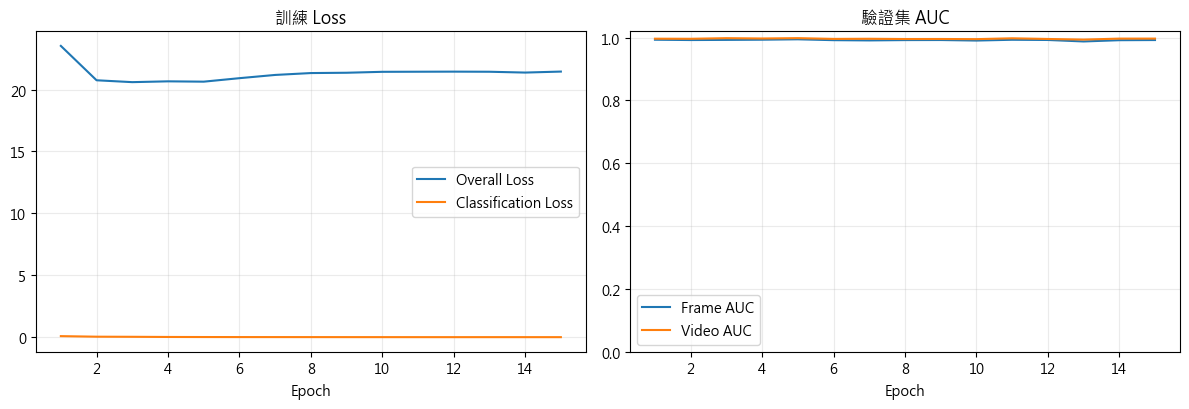

In [12]:
if not HISTORY_PATH.is_file():
    print("尚無 training_history.csv。")
else:
    history_df = pd.read_csv(HISTORY_PATH)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    axes[0].plot(
        history_df["epoch"],
        history_df["train_overall_loss"],
        label="Overall Loss",
    )
    axes[0].plot(
        history_df["epoch"],
        history_df["train_classification_loss"],
        label="Classification Loss",
    )
    axes[0].set_title("訓練 Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(
        history_df["epoch"],
        history_df["val_frame_auc"],
        label="Frame AUC",
    )
    axes[1].plot(
        history_df["epoch"],
        history_df["val_video_auc"],
        label="Video AUC",
    )
    axes[1].set_title("驗證集 AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1.02)
    axes[1].legend()
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 12. FF++ 獨立測試

載入第 5 個 epoch 的最佳權重。

In [13]:
if not RUN_TEST:
    print("RUN_TEST=False，尚未執行獨立 Test。")
elif SMOKE_TEST:
    raise ValueError("Smoke Test 不可輸出正式 Test 結論。")
elif not BEST_MODEL_PATH.is_file():
    raise FileNotFoundError(f"找不到最佳模型：{BEST_MODEL_PATH}")
else:
    best_checkpoint = torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE,
    )
    load_trainable_state(best_checkpoint["model_state_dict"])

    (
        test_frame_metrics,
        test_video_metrics,
        test_frame_df,
        test_video_df,
    ) = evaluate(test_loader, test_set)

    test_frame_df.to_csv(
        TEST_FRAME_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    test_video_df.to_csv(
        TEST_VIDEO_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    test_results = {
        "method": "Full Forensics Adapter under the existing data protocol",
        "best_epoch": int(best_checkpoint["epoch"]) + 1,
        "best_validation_video_auc": float(
            best_checkpoint["best_val_auc"]
        ),
        "frame_level": test_frame_metrics,
        "video_level": test_video_metrics,
    }
    TEST_METRICS_PATH.write_text(
        json.dumps(test_results, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(json.dumps(test_results, ensure_ascii=False, indent=2))

    print("\nFrame-level Classification Report")
    print(classification_report(
        test_frame_df["label"],
        test_frame_df["prediction"],
        target_names=["Real", "Fake"],
        digits=4,
        zero_division=0,
    ))
    print("Video-level Classification Report")
    print(classification_report(
        test_video_df["label"],
        test_video_df["prediction"],
        target_names=["Real", "Fake"],
        digits=4,
        zero_division=0,
    ))

  0%|          | 0/1120 [00:00<?, ?it/s]

{
  "method": "Full Forensics Adapter under the existing data protocol",
  "best_epoch": 5,
  "best_validation_video_auc": 0.9983163265306122,
  "frame_level": {
    "accuracy": 0.9370535714285714,
    "precision": 0.9631031220435194,
    "recall": 0.9089285714285714,
    "f1": 0.9352319706017456,
    "auc": 0.9814280731823981
  },
  "video_level": {
    "accuracy": 0.9535714285714286,
    "precision": 0.9774436090225563,
    "recall": 0.9285714285714286,
    "f1": 0.9523809523809523,
    "auc": 0.9877551020408163
  }
}

Frame-level Classification Report
              precision    recall  f1-score   support

        Real     0.9138    0.9652    0.9388      2240
        Fake     0.9631    0.9089    0.9352      2240

    accuracy                         0.9371      4480
   macro avg     0.9384    0.9371    0.9370      4480
weighted avg     0.9384    0.9371    0.9370      4480

Video-level Classification Report
              precision    recall  f1-score   support

        Real     0.9320

## 13. 混淆矩陣與 ROC Curve

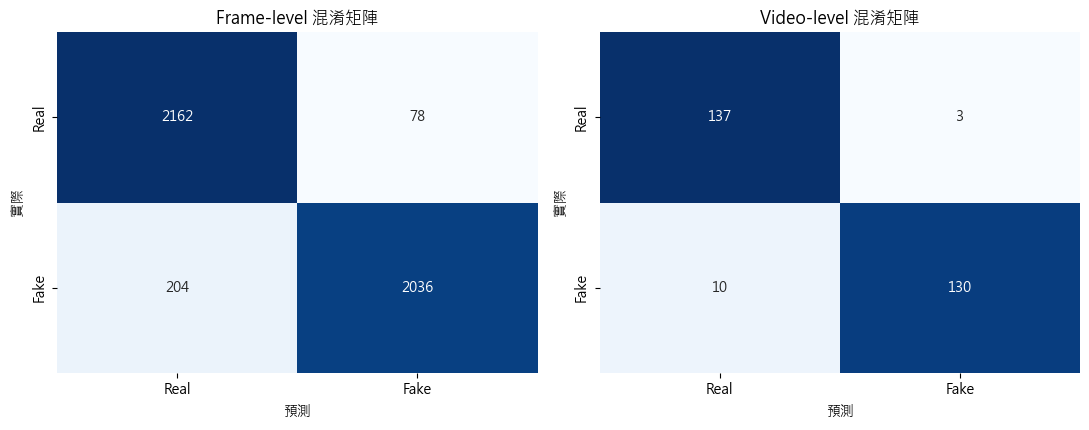

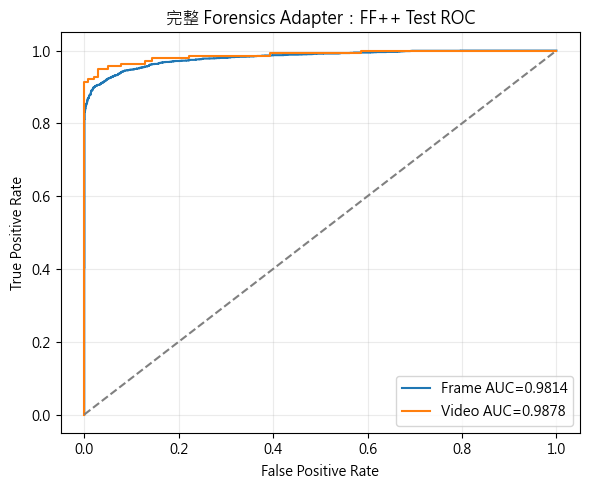

In [14]:
if "test_frame_df" not in globals():
    print("尚未執行正式 Test。")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    for axis, result_df, title in [
        (axes[0], test_frame_df, "Frame-level"),
        (axes[1], test_video_df, "Video-level"),
    ]:
        cm = confusion_matrix(
            result_df["label"],
            result_df["prediction"],
            labels=[0, 1],
        )
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"],
            ax=axis,
        )
        axis.set_title(f"{title} 混淆矩陣")
        axis.set_xlabel("預測")
        axis.set_ylabel("實際")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 5))
    for result_df, title in [
        (test_frame_df, "Frame"),
        (test_video_df, "Video"),
    ]:
        fpr, tpr, _ = roc_curve(
            result_df["label"],
            result_df["fake_probability"],
        )
        auc_value = roc_auc_score(
            result_df["label"],
            result_df["fake_probability"],
        )
        plt.plot(fpr, tpr, label=f"{title} AUC={auc_value:.4f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("完整 Forensics Adapter：FF++ Test ROC")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## FF++ 測試結果

| 層級 | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Frame | 0.9371 | 0.9631 | 0.9089 | 0.9352 | 0.9814 |
| Video | 0.9536 | 0.9774 | 0.9286 | 0.9524 | 0.9878 |

相對 03 基準（video AUC 0.9805），提升 0.0073。

如訓練曲線一節所述，這個差距不足以支持「完整 Adapter 明顯優於凍結基準」的結論——兩個模型在 FF++ Deepfakes 上都已接近上限。此外主幹規模不同（ViT-L/14 對 ViT-B/16），增益無法單獨歸因於 Adapter 結構。

方法之間的實質差異需要在訓練分布之外觀察，08 進行跨資料集測試。